# *Coursework: CHEN10081*

# Codes for the Graphs of the Calculated Data

Codes for the R-134a:

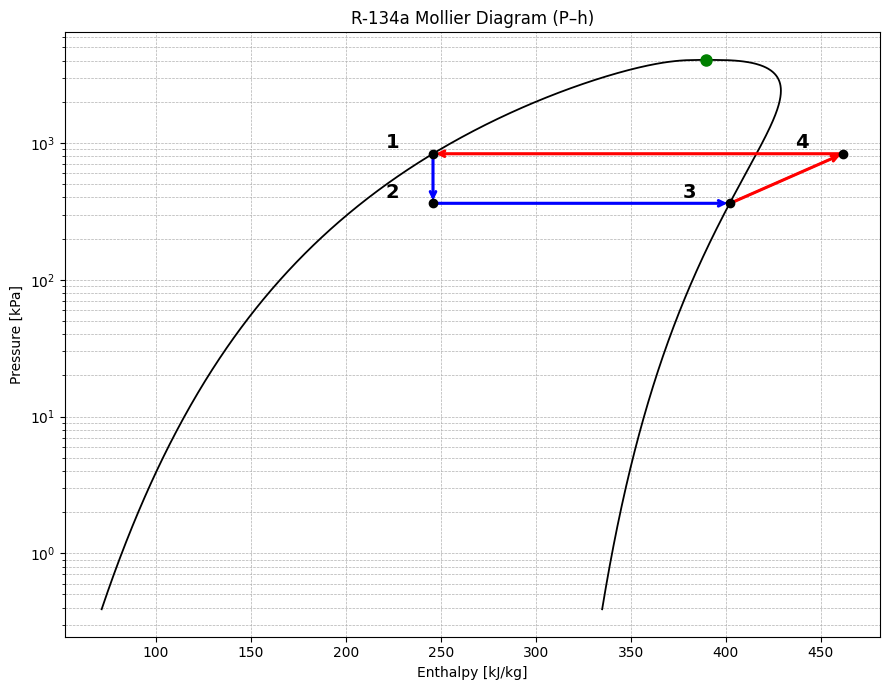

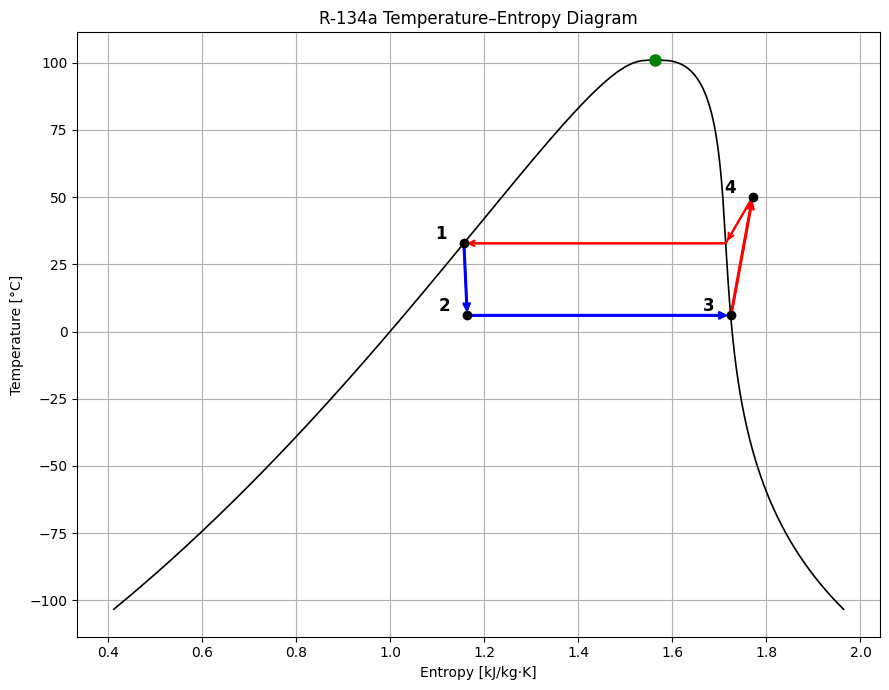

In [5]:
#R-134a Refrigeration Cycle

import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

fluid = "R134a"

# =========================================================
# GIVEN CYCLE DATA
# =========================================================
P = np.array([362.21, 362.21, 835.0, 835.0, 362.21])   # kPa
h = np.array([245.9, 402.3, 461.7, 245.9, 245.9])     # kJ/kg
s = np.array([1.164, 1.7247, 1.7707, 1.1569, 1.164])  # kJ/kg.K 
T = np.array([6.0, 6.0, 50.0, 32.8, 6.0])             # °C
labels = ["2", "3", "4", "1"]

# =========================================================
# SATURATION + CRITICAL DATA
# =========================================================
def saturation_and_critical(fluid, n=600):
    Tt = PropsSI("Ttriple", fluid)
    Tc = PropsSI("Tcrit", fluid)

    Ts = np.linspace(Tt + 1e-3, Tc - 1e-3, n)

    p, hL, hV, sL, sV = [], [], [], [], []
    for Ti in Ts:
        p.append(PropsSI("P","T",Ti,"Q",0,fluid)/1000)
        hL.append(PropsSI("H","T",Ti,"Q",0,fluid)/1000)
        hV.append(PropsSI("H","T",Ti,"Q",1,fluid)/1000)
        sL.append(PropsSI("S","T",Ti,"Q",0,fluid)/1000)
        sV.append(PropsSI("S","T",Ti,"Q",1,fluid)/1000)

    pc = PropsSI("Pcrit", fluid)/1000
    hc = PropsSI("H","T",Tc,"P",PropsSI("Pcrit",fluid),fluid)/1000
    sc = PropsSI("S","T",Tc,"P",PropsSI("Pcrit",fluid),fluid)/1000

    return np.array(p), np.array(hL), np.array(hV), np.array(sL), np.array(sV), Ts-273.15, pc, Tc-273.15, hc, sc

# =========================================================
# P–h DIAGRAM
# =========================================================

def draw_arrow(ax, x, y, i, color):
    ax.annotate(
        "",
        xy=(x[i+1], y[i+1]),
        xytext=(x[i], y[i]),
        arrowprops=dict(
            arrowstyle="->",
            lw=1.5,
            color=color
        )
    )

def plot_ph():
    fig, ax = plt.subplots(figsize=(9,7))
    p_sat, hL, hV, _, _, _, pc, _, hc, _ = saturation_and_critical(fluid)

    ax.plot(hL, p_sat, "k", lw=1.3)
    ax.plot(hV, p_sat, "k", lw=1.3)

    ax.plot(h[3:5], P[3:5], "b", lw=1.5)
    ax.plot(h[0:2], P[0:2], "b", lw=1.5)

    ax.plot(h[1:3], P[1:3], "r", lw=1.5)
    ax.plot(h[2:4], P[2:4], "r", lw=1.5)

    ax.scatter(h[:4], P[:4], c="k", zorder=5)

    for i in range(4):
        ax.text(h[i]-25, P[i]*1.1, labels[i], fontsize=14, fontweight="bold")

    ax.plot(hc, pc, "go", ms=8)

    ax.set_yscale("log")
    ax.set_xlabel("Enthalpy [kJ/kg]")
    ax.set_ylabel("Pressure [kPa]")
    ax.set_title("R-134a Mollier Diagram (P–h)")
    ax.grid(True, which="both", ls="--", lw=0.5)
    plt.tight_layout()
    
    draw_arrow(ax, h, P, 3, "blue")  
    draw_arrow(ax, h, P, 0, "blue")   
    draw_arrow(ax, h, P, 1, "red")    
    draw_arrow(ax, h, P, 2, "red")    

    plt.show()

# =========================================================
# T–s DIAGRAM 
# =========================================================

def draw_arrow(ax, x, y, i, color):
    ax.annotate(
        "",
        xy=(x[i+1], y[i+1]),
        xytext=(x[i], y[i]),
        arrowprops=dict(
            arrowstyle="->",
            lw=2.2,
            color=color
        )
    )


def plot_ts():
    fig, ax = plt.subplots(figsize=(9,7))
    _, _, _, sL, sV, Tsat, _, Tc, _, sc = saturation_and_critical(fluid)

    ax.plot(sL, Tsat, "k", lw=1.2)
    ax.plot(sV, Tsat, "k", lw=1.2)

    T4K = T[3] + 273.15
    s3p = PropsSI("S","T",T4K,"Q",1,fluid)/1000

    ax.plot([s[3], s[0], s[1]], [T[3], T[0], T[1]], "b", lw=1.5)

    ax.plot([s[1], s[2], s3p, s[3]],
            [T[1], T[2], T[3], T[3]], "r", lw=1.5)

    ax.scatter(s[:4], T[:4], c="k", zorder=5)
    for i in range(4):
        ax.text(s[i]-0.06, T[i]+1.5, labels[i],
                fontsize=12, fontweight="bold")

    ax.plot(sc, Tc, "go", ms=8)

    ax.set_xlabel("Entropy [kJ/kg·K]")
    ax.set_ylabel("Temperature [°C]")
    ax.set_title("R-134a Temperature–Entropy Diagram")
    ax.grid(True)
    plt.tight_layout()
    
    draw_arrow(ax, s, T, 3, "blue")   
    draw_arrow(ax, s, T, 0, "blue")   
    
    draw_arrow(ax, s, T, 1, "red")    

    ax.annotate(
        "",
        xy=(s3p, T[3]),
        xytext=(s[2], T[2]),
          arrowprops=dict(arrowstyle="->", lw=1.5, color="red")
    )

    ax.annotate(
        "",
        xy=(s[3], T[3]),
        xytext=(s3p, T[3]),
        arrowprops=dict(arrowstyle="->", lw=1.5, color="red")
    )

    plt.show()

# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":
    plot_ph()
    plot_ts()


Codes for the R-717:

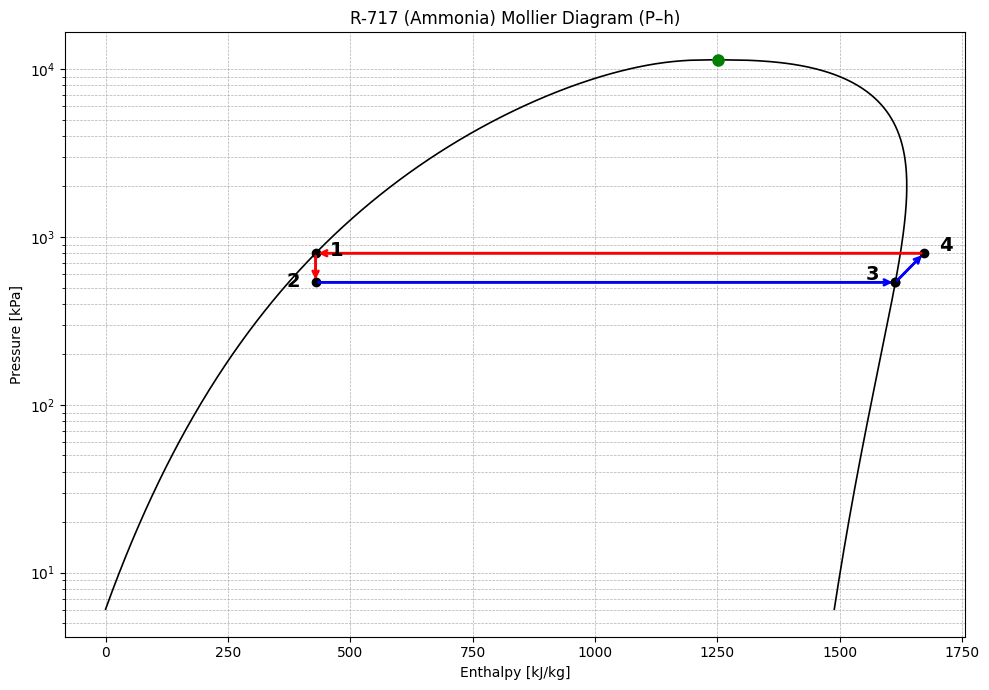

In [6]:
#R-717 (Ammonia) Refrigeration Cycle

import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

fluid = "R717"

P_evap = 536.65e3    
P_cond = 800e3       

def saturation_and_critical(fluid, n=600):
    Tt = PropsSI("Ttriple", fluid)
    Tc = PropsSI("Tcrit", fluid)
    Ts = np.linspace(Tt+1e-3, Tc-1e-3, n)
    p, hL, hV, sL, sV = [], [], [], [], []
    for Ti in Ts:
        p.append(PropsSI("P","T",Ti,"Q",0,fluid)/1000)
        hL.append(PropsSI("H","T",Ti,"Q",0,fluid)/1000)
        hV.append(PropsSI("H","T",Ti,"Q",1,fluid)/1000)
        sL.append(PropsSI("S","T",Ti,"Q",0,fluid)/1000)
        sV.append(PropsSI("S","T",Ti,"Q",1,fluid)/1000)
    pc = PropsSI("Pcrit", fluid)/1000
    Tc_val = PropsSI("Tcrit", fluid)-273.15
    hc = PropsSI("H","T",Tc,"P",PropsSI("Pcrit",fluid),fluid)/1000
    sc = PropsSI("S","T",Tc,"P",PropsSI("Pcrit",fluid),fluid)/1000
    return np.array(p), np.array(hL), np.array(hV), np.array(sL), np.array(sV), Ts-273.15, pc, Tc_val, hc, sc


def draw_arrow(ax, x, y, i, color, lw=2):
    ax.annotate("", xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
                arrowprops=dict(arrowstyle="->", lw=lw, color=color))

# =========================================================
# Compute cycle states
# =========================================================
# State 1: evaporator outlet (saturated vapor)
h1 = PropsSI("H","P",P_evap,"Q",1,fluid)/1000
s1 = PropsSI("S","P",P_evap,"Q",1,fluid)/1000
T1 = PropsSI("T","P",P_evap,"Q",1,fluid)-273.15

# State 3: condenser outlet (saturated liquid)
h3 = PropsSI("H","P",P_cond,"Q",0,fluid)/1000
s3 = PropsSI("S","P",P_cond,"Q",0,fluid)/1000
T3 = PropsSI("T","P",P_cond,"Q",0,fluid)-273.15

# State 2: compressor outlet (non-isentropic)
s2_increment = 0.02
s2 = s1 + s2_increment
h2 = PropsSI("H","P",P_cond,"S",s2*1000,fluid)/1000
T2 = PropsSI("T","P",P_cond,"S",s2*1000,fluid)-273.15

# State 4: expansion valve outlet (isenthalpic)
h4 = h3
T4 = PropsSI("T","P",P_evap,"H",h4*1000,fluid)-273.15
s4 = PropsSI("S","P",P_evap,"H",h4*1000,fluid)/1000

# Pack cycle arrays
P_cycle = np.array([P_evap,P_cond,P_cond,P_evap,P_evap])/1000   # kPa
h_cycle = np.array([h1,h2,h3,h4,h1])
s_cycle = np.array([s1,s2,s3,s4,s1])
T_cycle = np.array([T1,T2,T3,T4,T1])
labels = ["3", "4", "1", "2"]

# =========================================================
# P–h Diagram
# =========================================================
def plot_ph():
    fig, ax = plt.subplots(figsize=(10,7))
    p_sat, hL, hV, _, _, _, pc, _, hc, _ = saturation_and_critical(fluid)

    ax.plot(hL, p_sat, "k", lw=1.2)
    ax.plot(hV, p_sat, "k", lw=1.2)

    ax.plot(h_cycle, P_cycle, "k-o", lw=1.5, markersize=6)

    draw_arrow(ax, h_cycle, P_cycle, 0, "blue")   # 1→2
    draw_arrow(ax, h_cycle, P_cycle, 1, "red")    # 2→3
    draw_arrow(ax, h_cycle, P_cycle, 2, "red")    # 3→4
    draw_arrow(ax, h_cycle, P_cycle, 3, "blue")   # 4→1

    offsets_h = [-60, +30, +30, -60]
    offsets_p = [+20, +20, -30, -30]
    for i,label in enumerate(labels):
        ax.text(h_cycle[i]+offsets_h[i], P_cycle[i]+offsets_p[i], label,
                fontsize=14, fontweight="bold")

    ax.plot(hc, pc, "go", ms=8, label="Critical point")

    ax.set_yscale("log")
    ax.set_xlabel("Enthalpy [kJ/kg]")
    ax.set_ylabel("Pressure [kPa]")
    ax.set_title("R-717 (Ammonia) Mollier Diagram (P–h)")
    ax.grid(True, which="both", ls="--", lw=0.5)
    plt.tight_layout()
    plt.show()

# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":
    plot_ph()
   

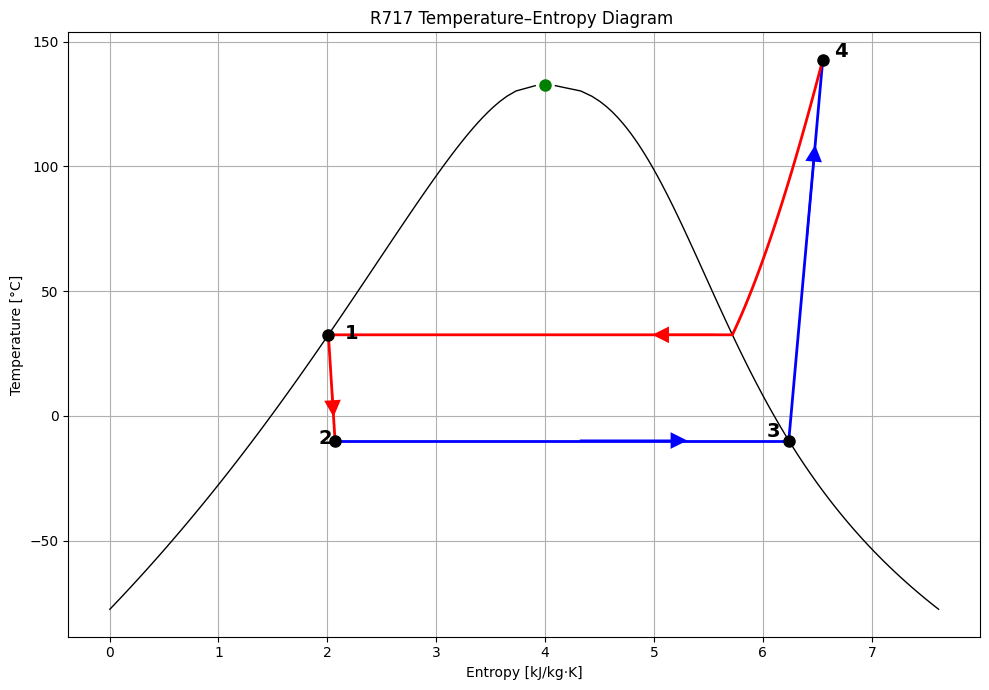

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from CoolProp.CoolProp import PropsSI 

# =========================================================
# T–s Diagram
# =========================================================

fluid = "R717"

# Pressure (kPa) - P_cycle[0] = Low, P_cycle[1] = High
P_cycle = np.array([291.5, 1254]) 
P_low = P_cycle[0] * 1000 # Pa
P_high = P_cycle[1] * 1000 # Pa

# State 1: Saturated Vapor (Evaporator Outlet, Q=1)
T1 = PropsSI("T", "P", P_low, "Q", 1, fluid) - 273.15
s1 = PropsSI("S", "P", P_low, "Q", 1, fluid) / 1000

# State 2: NON-ISENTROPIC Compression (s2 > s1, increased by 5%)
s2 = s1 * 1.05 
T2 = PropsSI("T", "P", P_high, "S", s2 * 1000, fluid) - 273.15

# State 3: Saturated Liquid (Condenser Outlet, Q=0)
T3 = PropsSI("T", "P", P_high, "Q", 0, fluid) - 273.15
s3 = PropsSI("S", "P", P_high, "Q", 0, fluid) / 1000
h3 = PropsSI("H", "P", P_high, "Q", 0, fluid) / 1000 # kJ/kg

# State 4: Expansion Valve Outlet (Isenthalpic, h4 = h3)
h4 = h3 
T4 = PropsSI("T", "P", P_low, "H", h4 * 1000, fluid) - 273.15
s4 = PropsSI("S", "P", P_low, "H", h4 * 1000, fluid) / 1000

T_cycle = np.array([T1, T2, T3, T4]) # °C
s_cycle = np.array([s1, s2, s3, s4]) # kJ/kg·K
labels = ["3", "4", "1", "2"]

STEPS_1_2 = 20
STEPS_2_2P = 30
STEPS_2P_3 = 30
STEPS_3_4 = 20
STEPS_4_1 = 20


def saturation_and_critical(fluid):
    T_crit = PropsSI("TCRIT", fluid) - 273.15
    T_crit_K = PropsSI("TCRIT", fluid)
    P_crit_Pa = PropsSI("PCRIT", fluid)
    s_crit = PropsSI("S", "T", T_crit_K, "P", P_crit_Pa, fluid) / 1000 
    
    T_min = PropsSI("TTRIPLE", fluid) - 273.15 + 0.1
    T_max = T_crit - 0.1
    
    Tsat_K = np.linspace(T_min + 273.15, T_max + 273.15, 100)
    Tsat = Tsat_K - 273.15
    
    sL = np.array([PropsSI("S", "T", T, "Q", 0, fluid) / 1000 for T in Tsat_K])
    sV = np.array([PropsSI("S", "T", T, "Q", 1, fluid) / 1000 for T in Tsat_K])
    
    return None, None, None, sL, sV, Tsat, None, T_crit, None, s_crit

def draw_arrow(ax, s_path, T_path, start_idx, color, arrow_len=5):

    end_idx = start_idx + arrow_len
    if end_idx < len(s_path):
        ax.annotate('', xy=(s_path[end_idx], T_path[end_idx]),
                    xytext=(s_path[start_idx], T_path[start_idx]),
                    arrowprops=dict(facecolor=color, edgecolor=color, shrink=0.05, linewidth=0, width=1.5))


def plot_ts_corrected():
    
    fig, ax = plt.subplots(figsize=(10,7))
    
    # Get Saturation Dome and Critical Point
    _, _, _, sL, sV, Tsat, _, Tc_val, _, sc = saturation_and_critical(fluid)

    # Saturation dome (Dashed black line)
    ax.plot(sL, Tsat, "k-", lw=1, label="Saturation Dome")
    ax.plot(sV, Tsat, "k-", lw=1)
    
    # ----------------------------------------------------
    # 1. Compression (1 → 2) (Non-Isentropic)
    # ----------------------------------------------------
    s_1_to_2 = np.linspace(s_cycle[0], s_cycle[1], STEPS_1_2)
    T_1_to_2 = np.linspace(T_cycle[0], T_cycle[1], STEPS_1_2)

    # ----------------------------------------------------
    # 2. Condensation (2 → 3) 
    # ----------------------------------------------------
    P_cond = P_cycle[1] * 1000  
    
    # Saturated Vapor state (Point 2') at Condenser Pressure
    T_sat_cond = PropsSI("T", "P", P_cond, "Q", 1, fluid) - 273.15
    s_sat_cond = PropsSI("S", "P", P_cond, "Q", 1, fluid) / 1000
    
    # --- Part A: De-superheating (2 → 2') --- (Isobaric curve)
    T_desuper = np.linspace(T_cycle[1], T_sat_cond, STEPS_2_2P, endpoint=False)
    s_desuper = []
    for t_val in T_desuper:
        s_val = PropsSI("S", "P", P_cond, "T", t_val + 273.15, fluid) / 1000
        s_desuper.append(s_val)
    s_desuper = np.array(s_desuper)
    
    # --- Part B: Isothermal Condensation (2' → 3) --- (Horizontal line on T-s)
    s_condense = np.linspace(s_sat_cond, s_cycle[2], STEPS_2P_3)
    T_condense = np.full_like(s_condense, T_sat_cond)

    # ----------------------------------------------------
    # 3. Expansion (3 → 4) (Isenthalpic)
    # ----------------------------------------------------
    s_3_to_4 = np.linspace(s_cycle[2], s_cycle[3], STEPS_3_4)
    T_3_to_4 = np.linspace(T_cycle[2], T_cycle[3], STEPS_3_4)

    # ----------------------------------------------------
    # 4. Evaporation (4 → 1) (Isobaric/Isothermal)
    # ----------------------------------------------------
    s_4_to_1 = np.linspace(s_cycle[3], s_cycle[0], STEPS_4_1)
    T_4_to_1 = np.linspace(T_cycle[3], T_cycle[0], STEPS_4_1)

    
    s_path = np.concatenate([s_1_to_2, s_desuper, s_condense, s_3_to_4, s_4_to_1])
    T_path = np.concatenate([T_1_to_2, T_desuper, T_condense, T_3_to_4, T_4_to_1])

    # Plot cycle path with correct colors and solid lines
    ax.plot(s_1_to_2, T_1_to_2, "b-", lw=2) 
    ax.plot(np.concatenate([s_desuper, s_condense]), np.concatenate([T_desuper, T_condense]), "r-", lw=2) 
    ax.plot(s_3_to_4, T_3_to_4, "r-", lw=2) 
    ax.plot(s_4_to_1, T_4_to_1, "b-", lw=2) 
    
    
    ax.plot(s_cycle, T_cycle, 
            marker='o',         
            linestyle='None',  
            color='k',          
            ms=8)               

   
    IDX_1_2 = 0                                       
    IDX_2_3 = STEPS_1_2 + 1                           
    IDX_3_4 = STEPS_1_2 + STEPS_2_2P + STEPS_2P_3     
    IDX_4_1 = IDX_3_4 + STEPS_3_4                     
    
    draw_arrow(ax, s_path, T_path, IDX_1_2 + STEPS_1_2 // 2, "b") # 1→2 (Compression)
    draw_arrow(ax, s_path, T_path, IDX_2_3 + (STEPS_2_2P + STEPS_2P_3) // 2, "r") # 2→3 (Condensation)
    draw_arrow(ax, s_path, T_path, IDX_3_4 + STEPS_3_4 // 2, "r") # 3→4 (Expansion)
    draw_arrow(ax, s_path, T_path, IDX_4_1 + STEPS_4_1 // 2, "b") # 4→1 (Evaporation)

    
    offsets_s = [-0.20, +0.10, +0.15, -0.15]
    offsets_T = [+1.5, +1, -1.5, -1.5]
    for i, label in enumerate(labels):
        ax.text(s_cycle[i]+offsets_s[i], T_cycle[i]+offsets_T[i], label,
                fontsize=14, fontweight="bold")

    # Critical point
    ax.plot(sc, Tc_val, "go", ms=8, label="Critical Point")

    ax.set_xlabel("Entropy [kJ/kg·K]")
    ax.set_ylabel("Temperature [°C]")
    ax.set_title(f"{fluid} Temperature–Entropy Diagram ")
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()


plot_ts_corrected()